# Decision Tree Classification for Telecom Customer Segmentation

**Author:** Noah de la Calzada

Classifying telecom customers into service tiers using demographic and account-level features with an interpretable decision tree model.

---
## 1. Problem Statement

Telecom companies need to classify customers into service tiers to target offers, allocate support resources, and reduce churn. The challenge: can we predict which of four customer segments (A, B, C, D) a customer belongs to using only demographic and account-level variables?

**Why decision trees?** They produce interpretable rules, handle mixed feature types natively, and make no linearity assumptions — ideal for a first-pass segmentation model where explainability matters as much as accuracy.

**Dataset:** 1,000 telecom customers with 11 features (tenure, age, income, education, region, etc.) and a four-class target (`custcat`).

---
## 2. Analysis

### 2.1 Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    auc,
)

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 10
sns.set_style("whitegrid")

%matplotlib inline

### 2.2 Load Data

In [ ]:
df = pd.read_csv("data/Telecust1.csv")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(10)

### 2.3 Exploratory Data Analysis

Inspect data types, summary statistics, and missing values.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   region   1000 non-null   int64 
 1   tenure   1000 non-null   int64 
 2   age      1000 non-null   int64 
 3   income   1000 non-null   int64 
 4   marital  1000 non-null   int64 
 5   address  1000 non-null   int64 
 6   ed       1000 non-null   int64 
 7   employ   1000 non-null   int64 
 8   retire   1000 non-null   int64 
 9   gender   1000 non-null   int64 
 10  reside   1000 non-null   int64 
 11  custcat  1000 non-null   object
dtypes: int64(11), object(1)
memory usage: 93.9+ KB


In [4]:
df.describe()

,region,tenure,age,income,marital,address,ed,employ,retire,gender,reside
count,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.0220,35.526000,41.684000,77.535000,0.495000,11.551000,2.671000,10.987000,0.047000,0.517000,2.331000
std,0.8162,21.359812,12.558816,107.044165,0.500225,10.086681,1.222397,10.082087,0.211745,0.499961,1.435793
min,1.0000,1.000000,18.000000,9.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.0000,17.000000,32.000000,29.000000,0.000000,3.000000,2.000000,3.000000,0.000000,0.000000,1.000000
50%,2.0000,34.000000,40.000000,47.000000,0.000000,9.000000,3.000000,8.000000,0.000000,1.000000,2.000000
75%,3.0000,54.000000,51.000000,83.000000,1.000000,18.000000,4.000000,17.000000,0.000000,1.000000,3.000000
max,3.0000,72.000000,77.000000,1668.000000,1.000000,55.000000,5.000000,47.000000,1.000000,1.000000,8.000000


In [5]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
region     0
tenure     0
age        0
income     0
marital    0
address    0
ed         0
employ     0
retire     0
gender     0
reside     0
custcat    0
dtype: int64


No missing values across all 1,000 rows. All 11 features are integer-typed; `custcat` is categorical (A, B, C, D).

Class distribution (custcat):
custcat
A    266
B    217
C    281
D    236
Name: count, dtype: int64


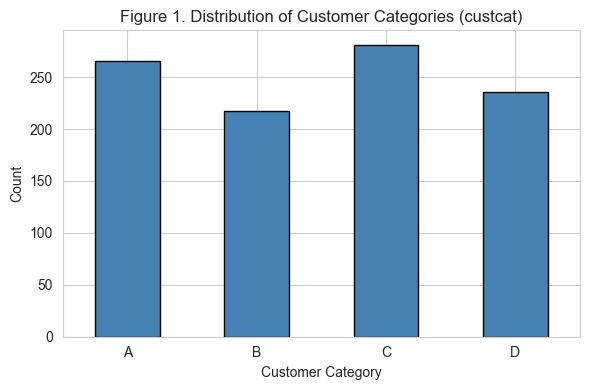

In [6]:
print("Class distribution (custcat):")
print(df["custcat"].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(6, 4))
counts = df["custcat"].value_counts().sort_index()
counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_xlabel("Customer Category")
ax.set_ylabel("Count")
ax.set_title("Figure 1. Distribution of Customer Categories (custcat)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

Roughly balanced across four categories. No severe class imbalance to address.

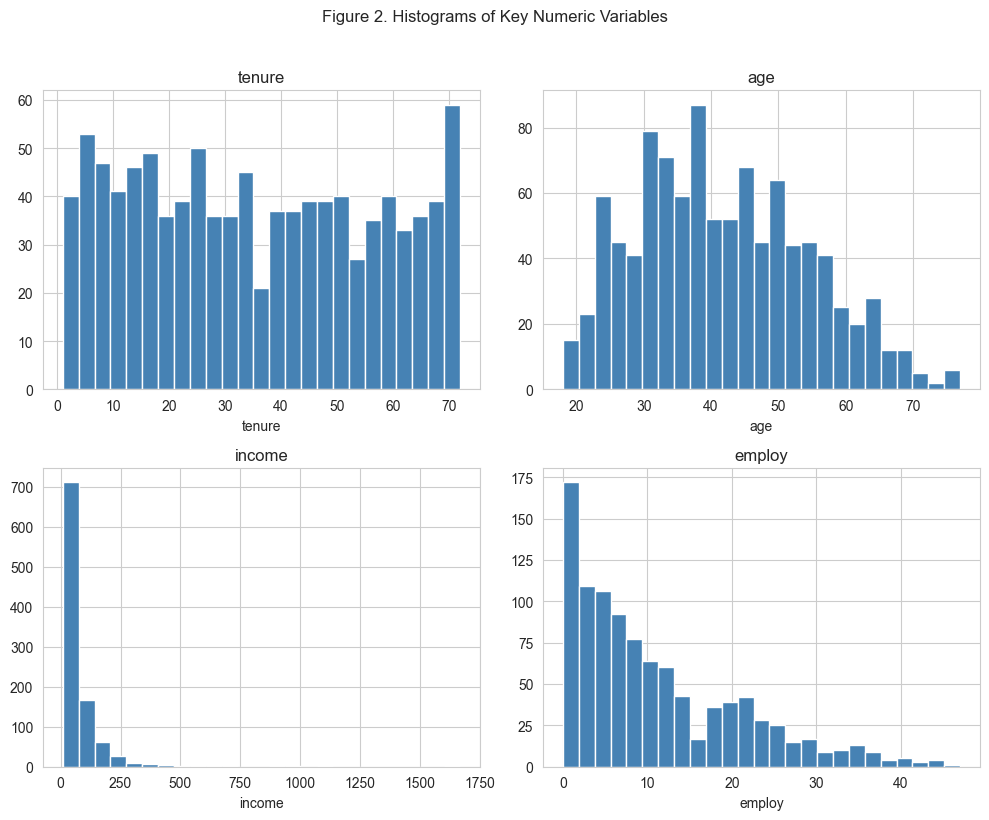

In [7]:
key_vars = ["tenure", "age", "income", "employ"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, col in enumerate(key_vars):
    ax = axes.flatten()[i]
    ax.hist(df[col].dropna(), bins=25, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)
fig.suptitle("Figure 2. Histograms of Key Numeric Variables", y=1.02)
plt.tight_layout()
plt.show()

Tenure and age are broadly distributed. Income and employment years are right-skewed — most customers cluster at lower values with a long tail.

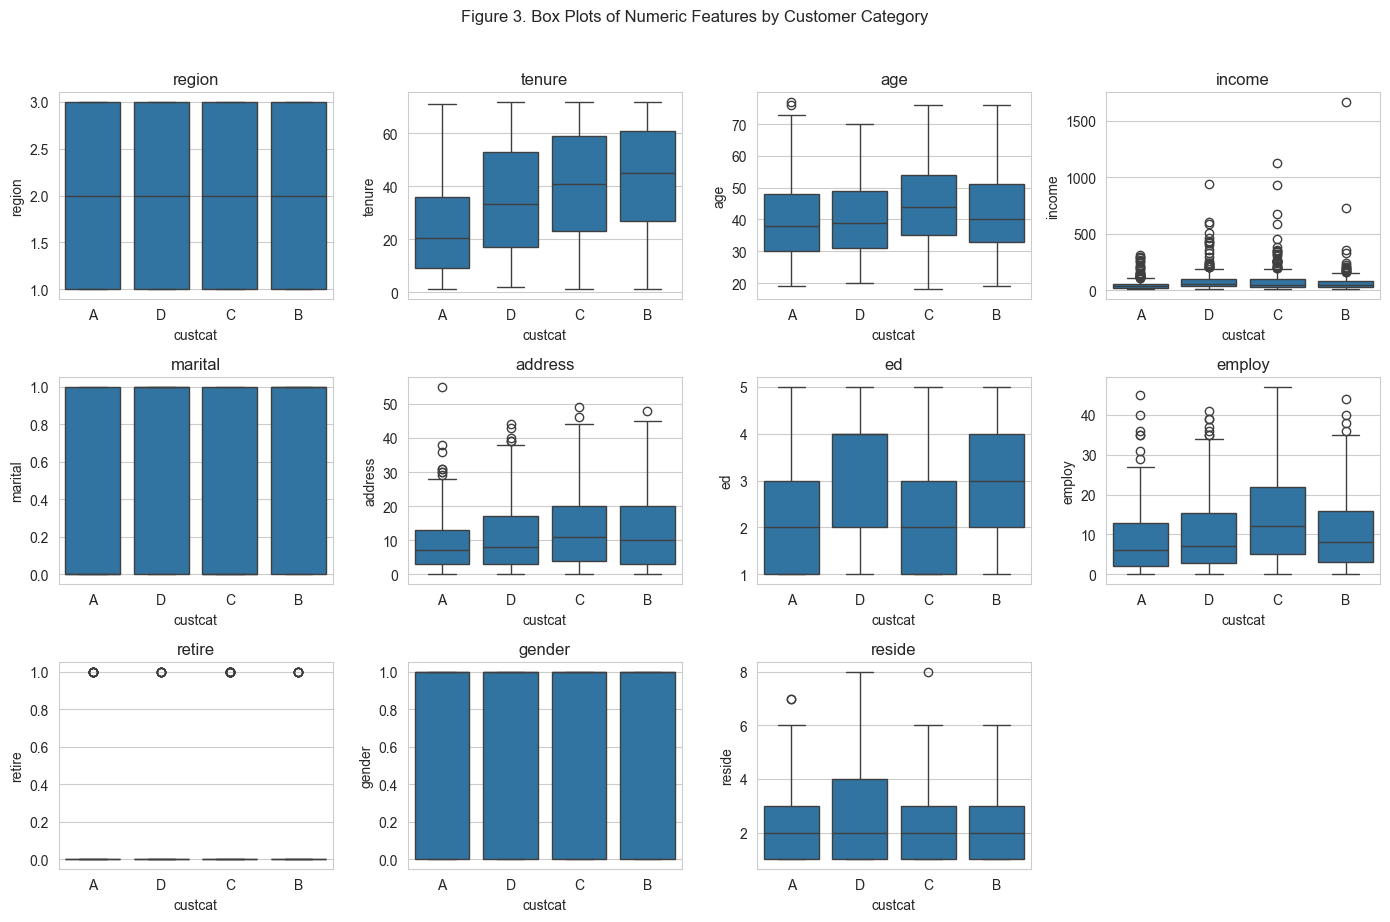

In [8]:
numeric_cols = [c for c in df.columns if c != "custcat" and df[c].dtype in ["int64", "float64"]]

ncols = 4
nrows = (len(numeric_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows))
axes_flat = np.array(axes).flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x="custcat", y=col, ax=axes_flat[i])
    axes_flat[i].set_title(col)
for j in range(len(numeric_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)
fig.suptitle("Figure 3. Box Plots of Numeric Features by Customer Category", y=1.02)
plt.tight_layout()
plt.show()

Some differentiation across categories (tenure and income distributions shift per segment), but no single feature cleanly separates all four groups. This signals a moderately difficult classification task.

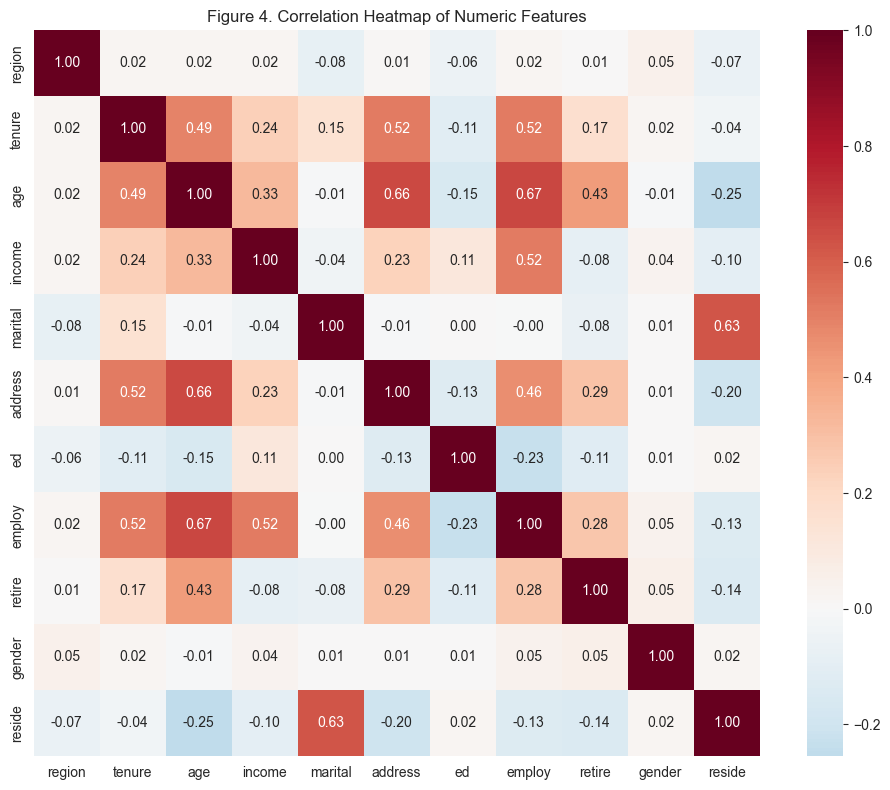

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True)
ax.set_title("Figure 4. Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

Several moderate correlations exist (age–employ at 0.67, age–address at 0.66, marital–reside at 0.63), though nothing extreme. Trees are immune to multicollinearity, but these relationships confirm some features carry overlapping signal.

### 2.4 Preprocessing

**Pipeline:** Encode target `custcat` (A/B/C/D) to numeric labels via `LabelEncoder`. Apply 80/20 stratified train-test split (`random_state=42`) to preserve class proportions. Standardize features with `StandardScaler` — not required for trees, but keeps the pipeline extensible for future model comparisons.

In [10]:
le = LabelEncoder()
y = le.fit_transform(df["custcat"])
feature_cols = [c for c in df.columns if c != "custcat"]
X = df[feature_cols].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Features:     {feature_cols}")
print(f"Classes:      {le.classes_.tolist()}")

Training set: 800 samples
Test set:     200 samples
Features:     ['region', 'tenure', 'age', 'income', 'marital', 'address', 'ed', 'employ', 'retire', 'gender', 'reside']
Classes:      ['A', 'B', 'C', 'D']


### 2.5 Model Fitting

#### Baseline Model

Default decision tree with no constraints, evaluated via 5-fold cross-validation.

In [11]:
base = DecisionTreeClassifier(random_state=42)
base.fit(X_train, y_train)
base_cv = cross_val_score(base, X_train, y_train, cv=5, scoring="accuracy")
print(f"Baseline (default) 5-fold CV accuracy: {base_cv.mean():.4f} (+/- {base_cv.std() * 2:.4f})")
print(f"Baseline tree depth: {base.get_depth()}")

Baseline (default) 5-fold CV accuracy: 0.3350 (+/- 0.0516)
Baseline tree depth: 18


Baseline overfits badly — depth 18 tree with only 33.5% CV accuracy. Hyperparameter tuning is essential.

#### Hyperparameter Tuning (GridSearchCV)

In [12]:
param_grid = {
    "max_depth": [3, 5, 7, 10, 12, 15],
    "criterion": ["gini", "entropy"],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5],
}

gs = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
gs.fit(X_train, y_train)

print(f"Best parameters: {gs.best_params_}")
print(f"Best 5-fold CV accuracy: {gs.best_score_:.4f}")

best_model = gs.best_estimator_

Best parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best 5-fold CV accuracy: 0.3675


#### Validation Curve

Visualizing the bias-variance tradeoff as a function of `max_depth`.

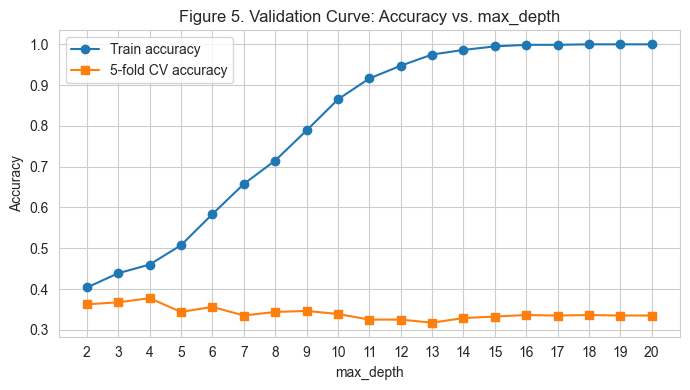

In [13]:
depths = list(range(2, 21))
train_scores = []
cv_scores = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    cv_scores.append(cross_val_score(tree, X_train, y_train, cv=5, scoring="accuracy").mean())
    tree.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, tree.predict(X_train)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depths, train_scores, "o-", label="Train accuracy")
ax.plot(depths, cv_scores, "s-", label="5-fold CV accuracy")
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.set_title("Figure 5. Validation Curve: Accuracy vs. max_depth")
ax.legend()
ax.set_xticks(depths)
plt.tight_layout()
plt.show()

Classic overfitting pattern: training accuracy climbs toward 100% while CV accuracy plateaus then declines. Grid search correctly selected a shallow tree (depth 3) to maximize generalization.

#### Tree Visualization

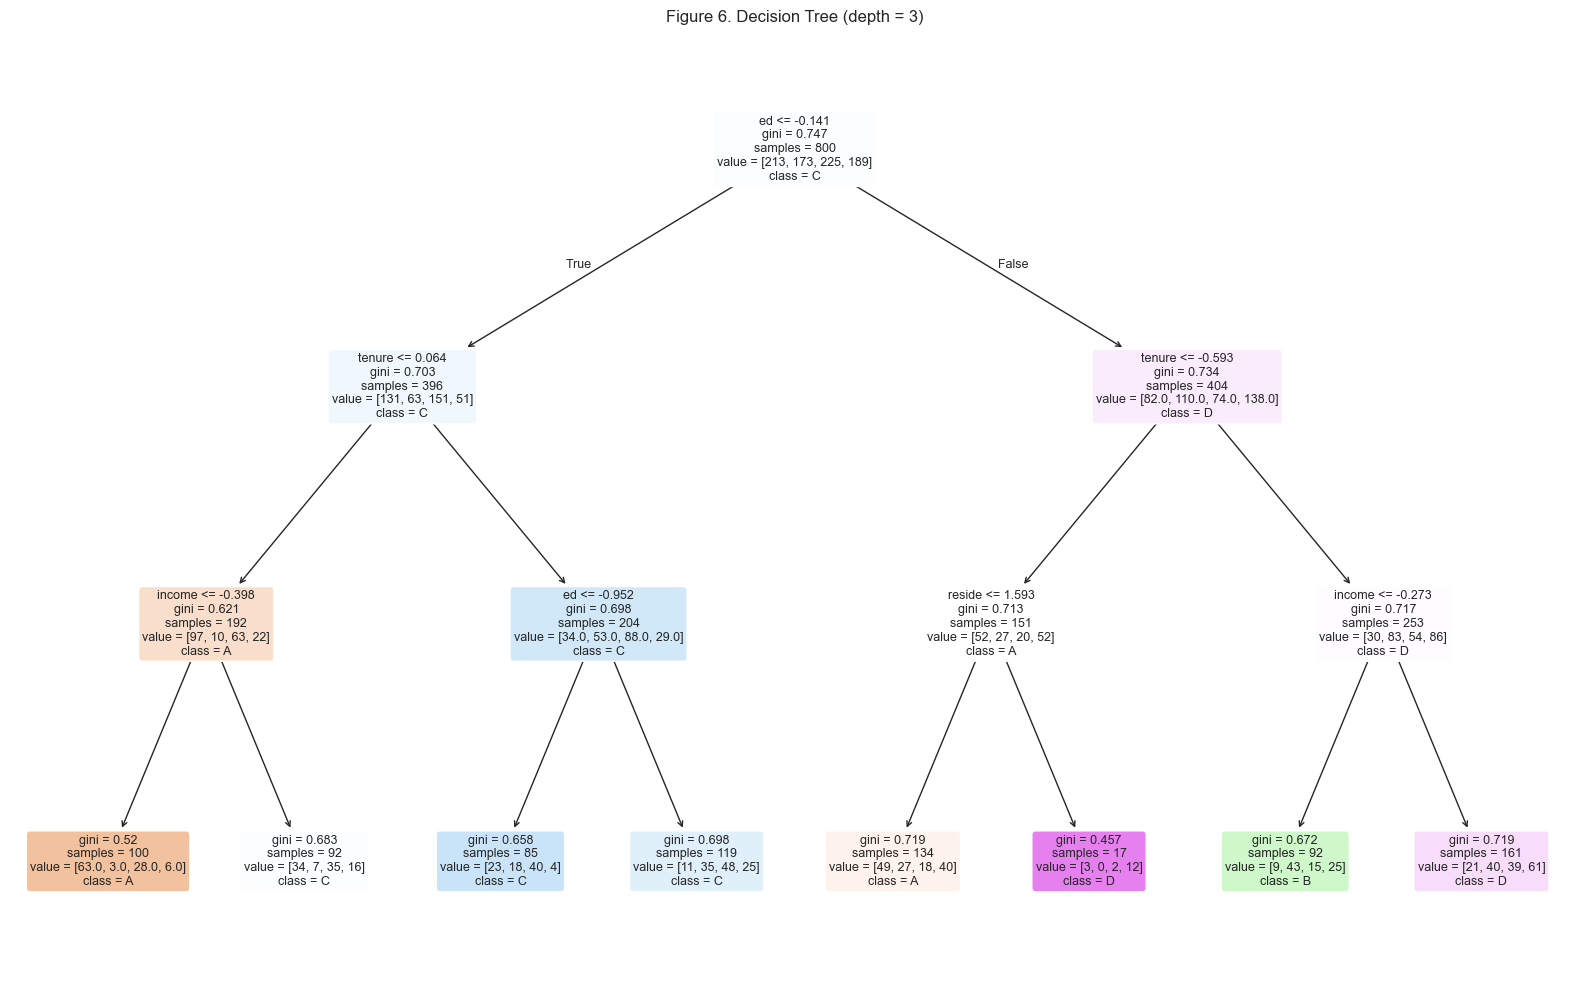


Tree depth: 3
Number of leaves: 8


In [14]:
plot_depth = min(best_model.get_depth(), 4)
class_names = le.classes_.tolist()

fig, ax = plt.subplots(figsize=(16, 10))
plot_tree(
    best_model,
    feature_names=feature_cols,
    class_names=class_names,
    filled=True,
    rounded=True,
    ax=ax,
    fontsize=9,
)
ax.set_title(f"Figure 6. Decision Tree (depth = {best_model.get_depth()})")
plt.tight_layout()
plt.show()

print(f"\nTree depth: {best_model.get_depth()}")
print(f"Number of leaves: {best_model.get_n_leaves()}")

---
## 3. Results

### 3.1 Feature Importance

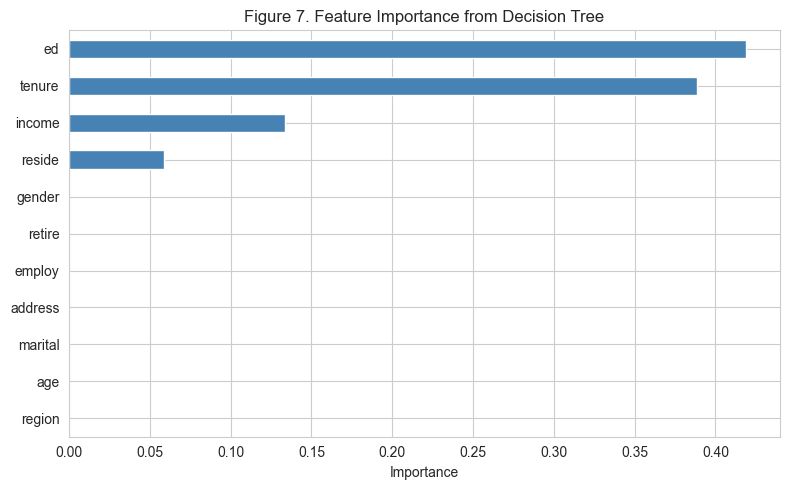


Feature importances (descending):
ed         0.419043
tenure     0.388546
income     0.133844
reside     0.058568
region     0.000000
age        0.000000
marital    0.000000
address    0.000000
employ     0.000000
retire     0.000000
gender     0.000000


In [15]:
imp = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
imp.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Importance")
ax.set_title("Figure 7. Feature Importance from Decision Tree")
plt.tight_layout()
plt.show()

print("\nFeature importances (descending):")
print(imp.sort_values(ascending=False).to_string())

**Key drivers:** `ed` (education level) at 42%, `tenure` at 39%, and `income` at 14% account for 95% of total importance. Region, gender, and retirement status contribute nothing — the tree ignores them entirely.

### 3.2 Test Set Evaluation

In [16]:
y_pred = best_model.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_acc:.4f}")
print(f"\nClassification Report (test set):")
print(classification_report(y_test, y_pred, target_names=class_names))

Test accuracy: 0.3700

Classification Report (test set):
              precision    recall  f1-score   support

           A       0.35      0.32      0.33        53
           B       0.36      0.20      0.26        44
           C       0.40      0.55      0.46        56
           D       0.35      0.36      0.36        47

    accuracy                           0.37       200
   macro avg       0.36      0.36      0.35       200
weighted avg       0.37      0.37      0.36       200



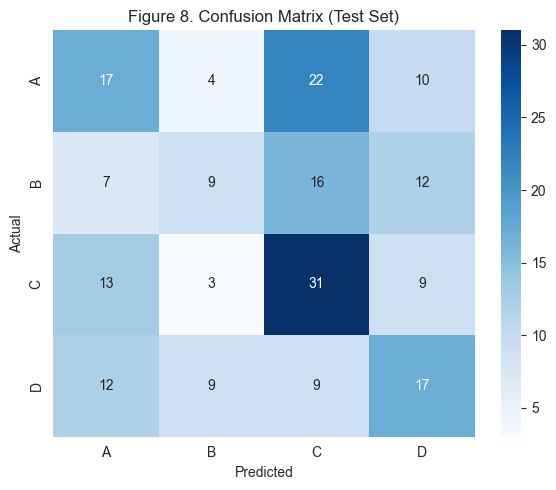

In [17]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Figure 8. Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

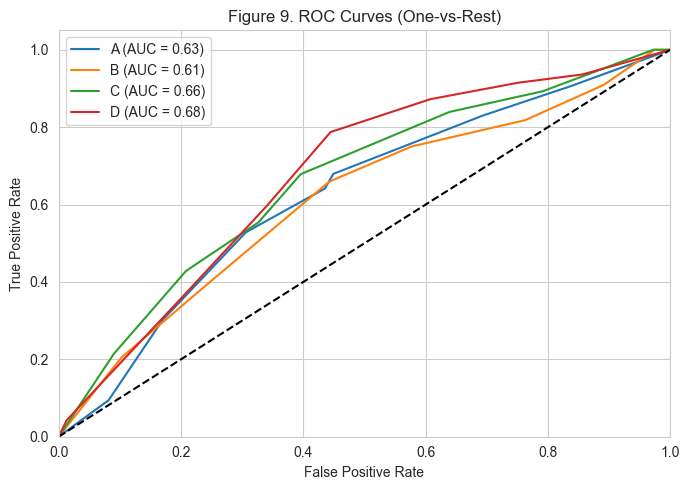

In [18]:
n_classes = len(class_names)
y_test_bin = label_binarize(y_test, classes=range(n_classes))
y_score = best_model.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(7, 5))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")
ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Figure 9. ROC Curves (One-vs-Rest)")
ax.legend()
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

### 3.3 Interpretation

**What the model does:** Predicts customer service tier from demographics and account tenure. The decision boundary is dominated by education level and tenure length.

**Per-class performance:** Category C has the highest recall (55%) — the model identifies these customers most reliably. Category B has the lowest recall (20%) — it's the hardest segment to distinguish.

**Practical implication:** Segment-specific campaigns should weight education level and tenure over demographic variables like region or gender. The confusion matrix shows errors are distributed across classes rather than concentrated, suggesting overlapping feature distributions between segments.

**ROC analysis:** AUC values range from 0.61 (B) to 0.68 (D) — moderate discriminative ability across all classes, consistently above the 0.50 random baseline.

**Honest assessment:** At 37% test accuracy (vs. 25% random chance for 4 classes), a single decision tree captures real signal but is insufficient as a standalone production model. This is expected — the value here is in the interpretable rules and feature importance insights, not raw prediction power. Ensemble methods (random forest, gradient boosting) would be the natural next step.

---
## 4. Conclusion

**What worked:**
- Education, tenure, and income are genuine predictors of customer segment
- Shallow tree (depth 3) selected via cross-validation prevents overfitting
- Model is fully interpretable — every prediction can be traced through 3 decision rules

**What didn't:**
- 37% accuracy leaves substantial room for improvement
- Category B is poorly separated from other segments
- No feature engineering was applied (interactions, binning, polynomial features)

**Next steps:**
- Ensemble methods (Random Forest, XGBoost) to improve prediction accuracy
- Feature engineering — interaction terms between education and tenure
- Cost-sensitive learning to weight high-value segment misclassifications
- Collect additional features (usage patterns, billing data) if available